## NData-Driven Growth Analytics: Optimizing User Cohorts and Marketing ROI for Entertainment Ticketing
El siguiete proyecto es un análisis para una compañia de venta de boletos. Los datos registran visitas pedidos y estadisticas de gastos de marketing desde junio del 2017 a mayo 2018
Los puntos a investigar son:

- cómo los clientes usan el servicio
- cuándo empiezan a comprar
- cuánto dinero aporta cada cliente a la compañía
- cuándo los ingresos cubren el costo de adquisición de los clientes.


Antes de iniciar el análisis es necesario preparar los datos y comprender su estructura.

In [1]:
#Se importan librearias necesarias para el análisis y la presentración de resultados.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Se importan las bases de datos
visits_log = pd.read_csv('/datasets/visits_log_us.csv') 
orders_log = pd.read_csv('/datasets/orders_log_us.csv')
costs_log = pd.read_csv('/datasets/costs_us.csv')

#Se revisa su estructura
visits_log.info()
print()
orders_log.info()
print()
costs_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  

Se observa que no hay datos nulos, sin embargo es necesario cambiar el tipo de las columnas que pueden tener fechas, por ejemplo 'dt' y 'Buy Ts', pero para saberlo con certeza hay que ver que efectivamente lo sean.

In [3]:
#Se imprime una muestra para ver el contenido y saber que tipo de dato le corresponde
print('End Ts samples:')
print(visits_log['End Ts'].sample(2))
print('Start Ts samples:')
print(visits_log['Start Ts'].sample(2))
print()
print('Buy Ts samples:')
print(orders_log['Buy Ts'].sample(2))
print()
print('"dt" samples:')
print(costs_log['dt'].sample(2))

End Ts samples:
74573     2017-11-17 16:47:00
183688    2018-03-07 08:06:00
Name: End Ts, dtype: object
Start Ts samples:
105318    2017-10-17 15:55:00
5768      2017-09-06 11:03:00
Name: Start Ts, dtype: object

Buy Ts samples:
42160    2018-03-26 20:57:00
31037    2018-01-25 19:35:00
Name: Buy Ts, dtype: object

"dt" samples:
131     2017-10-10
2078    2018-02-18
Name: dt, dtype: object


#### se preparan los datos
- Se observa que el contenido de las columnas debería ser datetime para realizar las operaciones adeucuadas en el análisis. 
- De igual forma, los nombres de las columnas de los DF visits_log y orders_log tienen mayusculas y espacios, lo que puede dificultar el trabajo más adelante, por lo que deben modificarse.

In [4]:
# Se cambian los nombres de las columnas de visits_log
visits_log.columns = visits_log.columns.str.lower().str.replace(' ', '_')
# Convierten las columnas de timestamp a datetime en visits_log
visits_log['start_ts'] = pd.to_datetime(visits_log['start_ts'])
visits_log['end_ts'] = pd.to_datetime(visits_log['end_ts'])

# # Se cambian los nombres de las columnas de orders_log
orders_log.columns = orders_log.columns.str.lower().str.replace(' ', '_')
# Convertir columna de timestamp en orders_log
orders_log['buy_ts'] = pd.to_datetime(orders_log['buy_ts'])

# Sólo se conveierte la 'dt' en costs_log
costs_log['dt'] = pd.to_datetime(costs_log['dt'])

# Se comprueba los datos nuevamente
print('información de visits_log')
visits_log.info()
print()
print('información de orders_log')
orders_log.info()
print()
print('información de costs_log')
costs_log.info()

información de visits_log
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB

información de orders_log
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB

información de c

## Informes y métricas
Una vez que los datos están en el formao adecuado, se puede comenzar con el análisis solicitado respeto al comportamiento de los visitantes. 
En este apartado se responden las siguientes preguntas:
- ¿Cuántas personas usan el servicio cada día, semana y mes?
- ¿Cuántas sesiones hay por día?
- ¿Cuál es la duración de cada sesión?
- ¿Con qué frecuencia los usuarios regresan?

### Visitas por día, semana y mes
Usando el DF visits_log se busca conocer las visitas al sitio web por día, semana y mes.

In [5]:

# para obter visitas de usuarios por día
users_by_day = visits_log.groupby(visits_log['start_ts'].dt.date)['uid'].nunique()

# visitas por semana
users_by_week = visits_log.groupby(visits_log['start_ts'].dt.to_period('W'))['uid'].nunique()

# visitas por mes
users_by_month = visits_log.groupby(visits_log['start_ts'].dt.to_period('M'))['uid'].nunique()

# Sesiones diarias
dayly_sessions = visits_log.groupby(visits_log['start_ts'].dt.date).size()

# Se agrega una columna al df visits_log con la duración de cada sesión
visits_log['session_duration'] = (visits_log['end_ts'] - visits_log['start_ts']).dt.total_seconds() / 60




### Para obtener la frecuancia de usuarios que regresan se presentan las métricas por día, semana y mes


In [6]:
# sesiones por usuario
sessions_per_user = visits_log.groupby('uid').size()

# frecuancia de retorno
average_frequency = sessions_per_user.mean()
print(f'Media de sesiones por usuario: {average_frequency:.2f}')

# se dentifica a los usuarios que regresan (más de 1 sesión)
returning_users = sessions_per_user[sessions_per_user > 1]
total_users = sessions_per_user.count()
print(f'Usuarios que regresan: {len(returning_users)} de {total_users}')
print(f'Porcentaje de usuarios que regresan: {len(returning_users)/total_users*100:.1f}%')



Media de sesiones por usuario: 1.58
Usuarios que regresan: 52128 de 228169
Porcentaje de usuarios que regresan: 22.8%


## vistas en los datos
- Se exponen los resultados con gráficos

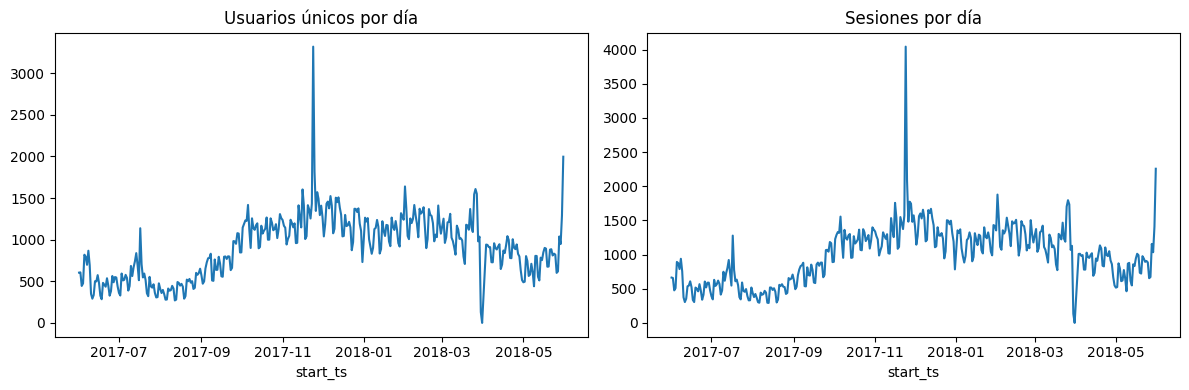

In [7]:
# Gráfico sobre 
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
users_by_day.plot(title='Usuarios únicos por día')
plt.subplot(1, 2, 2)
dayly_sessions.plot(title='Sesiones por día')
plt.tight_layout()
plt.show()

In [8]:
print("=== USUARIOS ÚNICOS POR DÍA ===")
print(f"Promedio diario: {users_by_day.mean():.0f} usuarios")
print(f"Máximo: {users_by_day.max()} usuarios")
print(f"Mínimo: {users_by_day.min()} usuarios")
print()

print("=== USUARIOS ÚNICOS POR SEMANA ===") 
print(f"Promedio semanal: {users_by_week.mean():.0f} usuarios")
print(f"Máximo: {users_by_week.max()} usuarios")
print(f"Mínimo: {users_by_week.min()} usuarios")
print()

print("=== SESIONES DIARIAS ===")
print(f"Promedio diario: {dayly_sessions.mean():.0f} sesiones")
print(f"Máximo: {dayly_sessions.max()} sesiones")
print()

=== USUARIOS ÚNICOS POR DÍA ===
Promedio diario: 908 usuarios
Máximo: 3319 usuarios
Mínimo: 1 usuarios

=== USUARIOS ÚNICOS POR SEMANA ===
Promedio semanal: 5716 usuarios
Máximo: 10586 usuarios
Mínimo: 2021 usuarios

=== SESIONES DIARIAS ===
Promedio diario: 987 sesiones
Máximo: 4042 sesiones



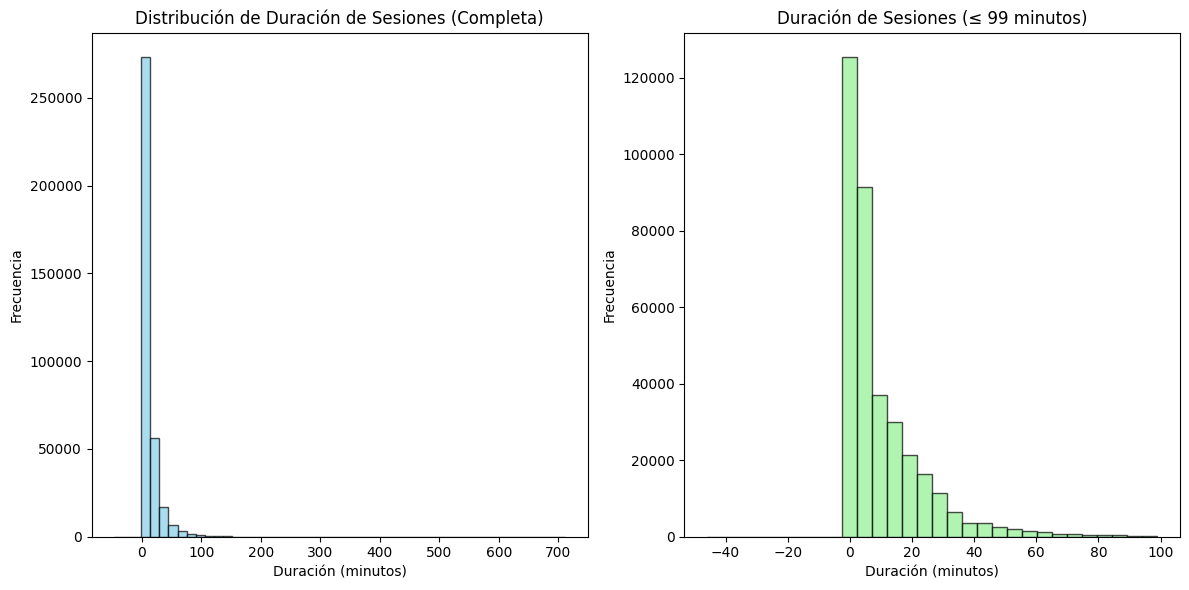

In [9]:
#histograma para observar la duración promedio de las visitas

plt.figure(figsize=(12, 6))

# Subplot 1: Histograma completo
plt.subplot(1, 2, 1)
plt.hist(visits_log['session_duration'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución de Duración de Sesiones (Completa)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

#Considerando que los valores atipicos pueden hacer ilegible la gráfica, se propone una donde los valores más altos no aparezcan
plt.subplot(1, 2, 2)

filtered_duration = visits_log[visits_log['session_duration'] <= 99]['session_duration']
plt.hist(filtered_duration, bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Duración de Sesiones (≤ 99 minutos)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

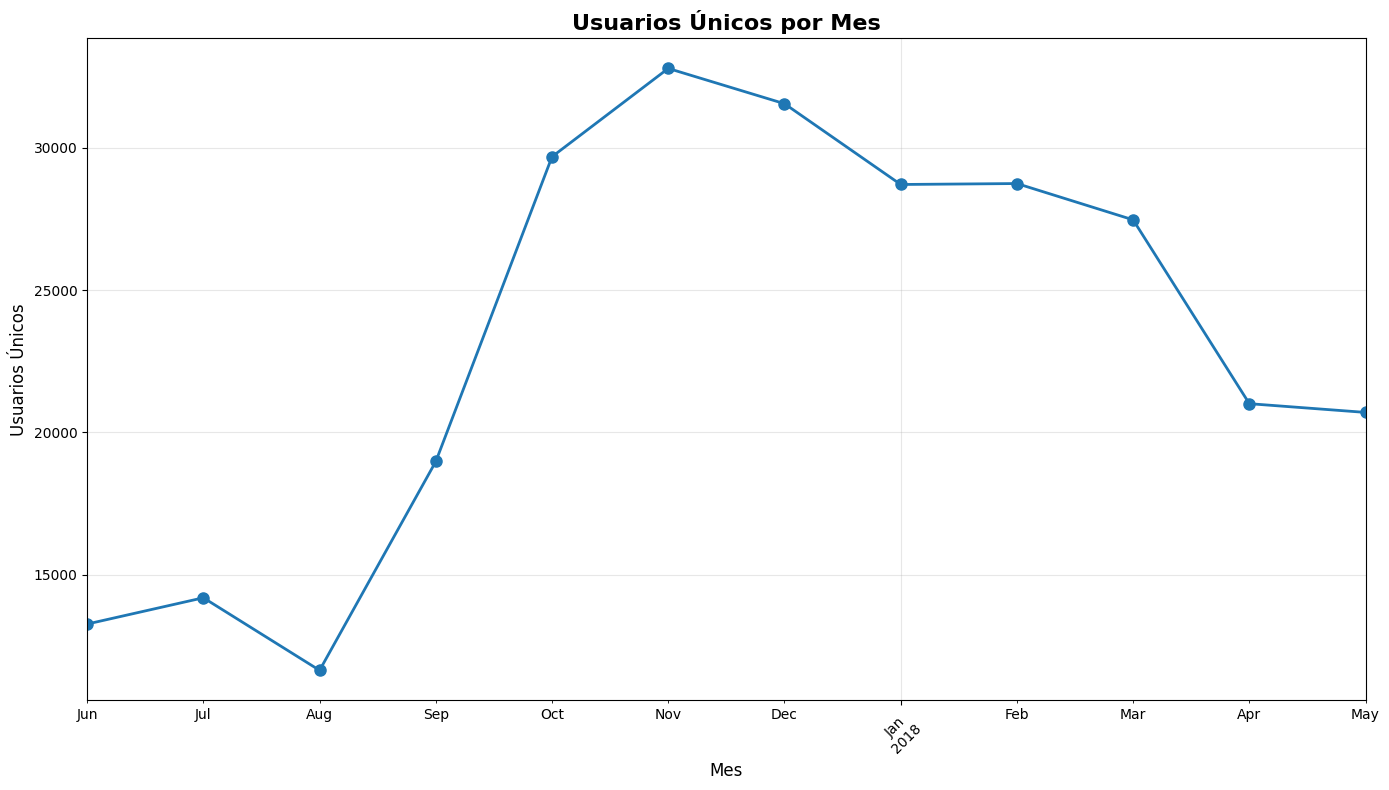

In [10]:
# Gráfico mensual para comprobar las tendencias observadas en los datos anteriores
plt.figure(figsize=(14, 8))
users_by_month.plot(kind='line', marker='o', linewidth=2, markersize=8)
plt.title('Usuarios Únicos por Mes', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Usuarios Únicos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Analisis preiminar sobre las visitas al sitio:
- Se observa que los picos de ventas estan cerca de las festividades navideñas, de octubbre a diciembre, con noviembre como el mes con más usuarios únicos en el sitio.
- Por su parte, agosto y abril parecen ser los meses donde hay menor registro de usuarios, y los meses intermedios tambien son bajos, quizá por el periodo estival y de vacaciones.

# Analisis de cohortes para ventas
Para complementar los primeros datos explorados es necesario generar cohortes, en este caso se optó por el tiempo de conversión.

In [11]:
# se obtiene primero la primera compra de cada ausuario
first_visit = visits_log.groupby('uid')['start_ts'].min()

# se obtiene la primera compra del usuario
first_purchase = orders_log.groupby('uid')['buy_ts'].min()

# Se crea un df con los valores de conversión
conversion_data = conversion_data = pd.merge(first_visit, first_purchase, 
                          left_index=True, right_index=True, 
                          how='left')
# se agrega el tiempo de conversión al df para generar cohortes
conversion_data['days_to_conversion'] = (conversion_data['buy_ts'] - conversion_data['start_ts']).dt.days

Estadísticas de días hasta conversión:
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: days_to_conversion, dtype: float64

Valor máximo: 363.0
Valor mínimo: 0.0
Conversiones en primeros 30 días: 31621 de 36523
Porcentaje: 86.6%


Text(0, 0.5, 'Número de conversiones')

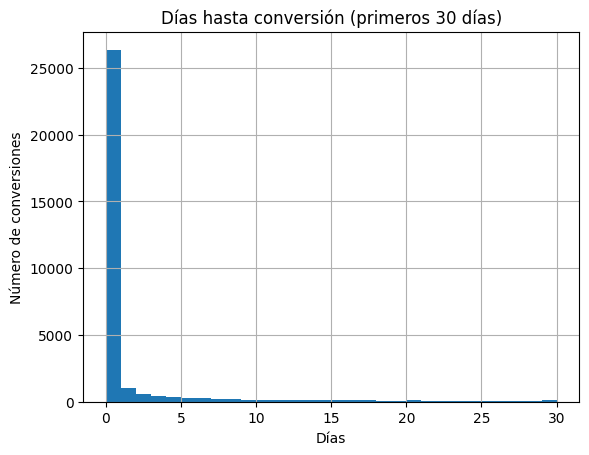

In [12]:
converted_users = conversion_data.dropna(subset=['days_to_conversion']).copy()
print("Estadísticas de días hasta conversión:")
print(converted_users['days_to_conversion'].describe())
print(f"\nValor máximo: {converted_users['days_to_conversion'].max()}")
print(f"Valor mínimo: {converted_users['days_to_conversion'].min()}")

early_conversions = converted_users[converted_users['days_to_conversion'] <= 30]
print(f"Conversiones en primeros 30 días: {len(early_conversions)} de {len(converted_users)}")
print(f"Porcentaje: {len(early_conversions)/len(converted_users)*100:.1f}%")


early_conversions['days_to_conversion'].hist(bins=30)
plt.title('Días hasta conversión (primeros 30 días)')
plt.xlabel('Días')
plt.ylabel('Número de conversiones')

Considerando las metricas las cohortes con más sentido para el proyecto son:


In [13]:
# se usa una función con un loop for para categorizar usuarios en cohortes
def categorize_conversion_time(days):
    if days == 0:
        return 'C0' #conversión inmediata
    elif days == 1:
        return 'C1)' #conversión de un día
    elif 2 <= days <= 7:
        return 'C2-7' #conversón de 2 a 7 días
    elif 8 <= days <= 30:
        return 'C8-30' #conversión de 8 a 30 días
    else:
        return 'C30+' #mayor a 30 días

# se aplica la función sobre los días
converted_users['cohort_conversion'] = converted_users['days_to_conversion'].apply(categorize_conversion_time)

#se imprime una muestra del estado del nuevo df
print(converted_users.sample(10))

                                start_ts              buy_ts  \
uid                                                            
9325544273527433209  2017-10-25 12:25:00 2017-10-25 12:43:00   
2963803957233394857  2017-06-23 09:10:00 2017-06-23 09:12:00   
16160477998151490320 2018-02-16 10:01:00 2018-02-16 10:01:00   
9233271499025686918  2017-11-13 22:47:00 2017-11-13 23:01:00   
13796776461870456490 2017-12-18 01:27:00 2017-12-18 01:28:00   
9252326396341161909  2017-11-16 12:18:00 2018-03-03 18:31:00   
16828858318026296648 2017-12-23 00:09:00 2017-12-23 00:29:00   
17707737309090693355 2017-12-08 15:47:00 2017-12-08 15:48:00   
7031039535921826486  2018-03-02 15:05:00 2018-03-02 15:18:00   
4933841428294388246  2017-09-03 21:30:00 2017-09-03 21:44:00   

                      days_to_conversion cohort_conversion  
uid                                                         
9325544273527433209                  0.0                C0  
2963803957233394857                  0.0        

Se presentan las cohortes y sus distribuciones

Distribución de usuarios por cohorte:
C0       26363
C30+      4902
C8-30     2178
C2-7      2069
C1)       1011
Name: cohort_conversion, dtype: int64

Porcentajes:
C0       72.2
C30+     13.4
C8-30     6.0
C2-7      5.7
C1)       2.8
Name: cohort_conversion, dtype: float64


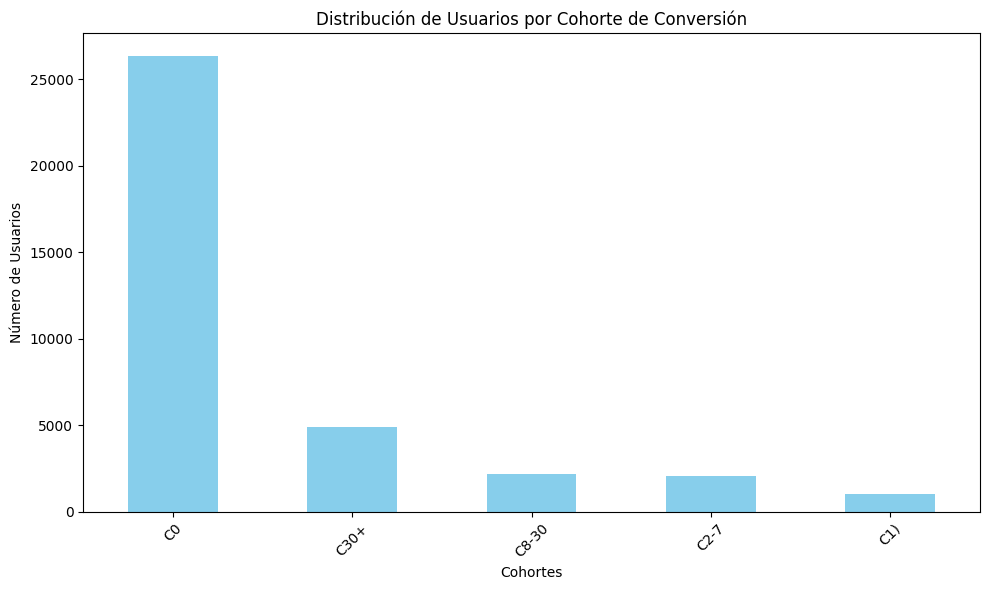

In [14]:
cohort_distribution = converted_users['cohort_conversion'].value_counts()
print("Distribución de usuarios por cohorte:")
print(cohort_distribution)
print("\nPorcentajes:")
print((cohort_distribution / cohort_distribution.sum() * 100).round(1))

plt.figure(figsize=(10, 6))
cohort_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribución de Usuarios por Cohorte de Conversión')
plt.xlabel('Cohortes')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>


</div>

Ahora se trabaja sobre los pedidos, el ticket promedio y el LTV

In [15]:

cohort_orders = pd.merge(
    converted_users[['cohort_conversion']], 
    orders_log, 
    left_index=True, 
    right_on='uid', 
    how='inner'
)

print(f"Total de órdenes en el análisis: {len(cohort_orders)}")
print(f"Usuarios únicos: {cohort_orders['uid'].nunique()}")


cohort_analysis = cohort_orders.groupby('cohort_conversion').agg({
    'uid': 'nunique',  # Número de usuarios únicos
    'revenue': ['count', 'mean', 'sum']  # Pedidos, ticket promedio, revenue total
}).round(2)

# Aplanar los nombres de columnas
cohort_analysis.columns = ['usuarios', 'total_pedidos', 'ticket_promedio', 'revenue_total']

print("Análisis por Cohorte:")
print(cohort_analysis)


Total de órdenes en el análisis: 50415
Usuarios únicos: 36523
Análisis por Cohorte:
                   usuarios  total_pedidos  ticket_promedio  revenue_total
cohort_conversion                                                         
C0                    26363          34237             4.56      156075.98
C1)                    1011           1812             5.90       10684.87
C2-7                   2069           3451             4.79       16534.65
C30+                   4902           7163             5.50       39431.16
C8-30                  2178           3752             7.82       29330.54


In [16]:
# Agregar las métricas que faltan
cohort_analysis['pedidos_por_usuario'] = (cohort_analysis['total_pedidos'] / cohort_analysis['usuarios']).round(2)
cohort_analysis['LTV_por_usuario'] = (cohort_analysis['revenue_total'] / cohort_analysis['usuarios']).round(2)

print("\n=== ANÁLISIS COMPLETO CON LTV ===")
print(cohort_analysis)


=== ANÁLISIS COMPLETO CON LTV ===
                   usuarios  total_pedidos  ticket_promedio  revenue_total  \
cohort_conversion                                                            
C0                    26363          34237             4.56      156075.98   
C1)                    1011           1812             5.90       10684.87   
C2-7                   2069           3451             4.79       16534.65   
C30+                   4902           7163             5.50       39431.16   
C8-30                  2178           3752             7.82       29330.54   

                   pedidos_por_usuario  LTV_por_usuario  
cohort_conversion                                        
C0                                1.30             5.92  
C1)                               1.79            10.57  
C2-7                              1.67             7.99  
C30+                              1.46             8.04  
C8-30                             1.72            13.47  


In [17]:
print("\n=== RESUMEN POR COHORTE ===")
print("¿Cuánto dinero traen los usuarios de cada cohorte?\n")

for cohort in cohort_analysis.index:
    usuarios = cohort_analysis.loc[cohort, 'usuarios']
    pedidos_por_usuario = cohort_analysis.loc[cohort, 'pedidos_por_usuario']
    ticket_promedio = cohort_analysis.loc[cohort, 'ticket_promedio']
    ltv = cohort_analysis.loc[cohort, 'LTV_por_usuario']
    
    print(f" {cohort}:")
    print(f"   • {usuarios:,} usuarios")
    print(f"   • {pedidos_por_usuario} pedidos por usuario")
    print(f"   • ${ticket_promedio} ticket promedio")
    print(f"   • ${ltv} LTV por usuario")
    print()


=== RESUMEN POR COHORTE ===
¿Cuánto dinero traen los usuarios de cada cohorte?

 C0:
   • 26,363 usuarios
   • 1.3 pedidos por usuario
   • $4.56 ticket promedio
   • $5.92 LTV por usuario

 C1):
   • 1,011 usuarios
   • 1.79 pedidos por usuario
   • $5.9 ticket promedio
   • $10.57 LTV por usuario

 C2-7:
   • 2,069 usuarios
   • 1.67 pedidos por usuario
   • $4.79 ticket promedio
   • $7.99 LTV por usuario

 C30+:
   • 4,902 usuarios
   • 1.46 pedidos por usuario
   • $5.5 ticket promedio
   • $8.04 LTV por usuario

 C8-30:
   • 2,178 usuarios
   • 1.72 pedidos por usuario
   • $7.82 ticket promedio
   • $13.47 LTV por usuario



aspectos remarcables del análisis de cohortes:
- la cohorte **c8-30** es tiene un buen número de ordenes por usuario, mayor ticket promedio y el LTv más alto. No obstante es la segunda con menos usuarios.
- **c1** es algo similar pero con menos usuarios incluso.
===== Habría que produndizar en estas cohortes para conocer mejor el perfil y saber la razón de este comportamiento


- **c0**, aunque tiene el mayor numero de usuarios su ltv no es muy alto y su ticket promedio tampoco es muy alto, no obstante tiene una cantidad de usuarios mucho más alta, quizá habría que profundizar en su experienza para hacer que su LTV aumente.


- aunque el ticket promedio de **C30+** no es muy alto, su LTV es mayor, habría que buscar una manera de retener a estos usuarios

- En el caso de **c2-7** no es una cohorte muy fuerte, sin embrgo tiene un buen número de usuarios con los que se puede trabajar. Hay que observar de dónde provienen las visitas de estos usuarios para planear una estrategía adecuada.


# ANALISIS DE MARKETING
Ahora, para poder saber en cuál canal debería potenciarse, se procede a concocer cuanto los aspectos relacionado sal marketing. 
- primero se obtiene los costos por cada fuente o plataforma
- despues se conoce el costo de adquisición
- finalmente se presenta el ROMI por cada medio

In [18]:
#se hace un series con los costos totales por fuente
costs_by_source = costs_log.groupby('source_id')['costs'].sum()
print(costs_by_source)

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


Considerando que se cuentan con el nombre de las fuentes, se mantienen los números.
aquí se puede observar que la fuente **3** es la de mayor ingreso, seguido de la **4** y la **5**. 

Las fuentes **9**, **10** y **1** son las de menor ingreso. Aunque la uno está es casi 4 veces mayor que las **9** y **10**

In [19]:
# Se cuentan los usuarios únicos por fuente, ya que es más releveante que el número de sesiones
users_per_source = visits_log.groupby('source_id')['uid'].nunique()
print("Usuarios únicos por fuente:")
print(users_per_source)

Usuarios únicos por fuente:
source_id
1     18999
2     26245
3     74756
4     83525
5     56974
6         6
7        34
9      9264
10     8067
Name: uid, dtype: int64


Resulta significativo que la fuente **8** no aparece, así como que la **6** y **7** no tienen impacto pues no sus usuarios son muy pocos y no generan ganancias, ya que no figuran en el resultado previo.

In [20]:
# con los datos necesario se busca el CAC por fuente
cac_by_source = costs_by_source / users_per_source
print("CAC por fuente:")
print(cac_by_source.round(2))

CAC por fuente:
source_id
1     1.10
2     1.63
3     1.89
4     0.73
5     0.91
6      NaN
7      NaN
9     0.60
10    0.72
dtype: float64


Lo que resulta es muy interesante pues se puede ver que el CAC de la fuente **4** y **5** son más bajos que la **3** aunque la ganancia es más del doble. A continuación se presenta un resumen:

In [21]:
marketing_summary = pd.DataFrame({
    'costos_totales': costs_by_source,
    'usuarios_unicos': users_per_source,
    'cac': costs_by_source / users_per_source
}).round(2)
print(marketing_summary)

           costos_totales  usuarios_unicos   cac
source_id                                       
1                20833.27            18999  1.10
2                42806.04            26245  1.63
3               141321.63            74756  1.89
4                61073.60            83525  0.73
5                51757.10            56974  0.91
6                     NaN                6   NaN
7                     NaN               34   NaN
9                 5517.49             9264  0.60
10                5822.49             8067  0.72


In [22]:
# Para calcular el ROMI es necesari oobtener el ingreso por fuente
revenue_by_source = visits_log.merge(orders_log, on='uid', how='inner')
revenue_totals = revenue_by_source.groupby('source_id')['revenue'].sum()
print("Ingresos totales por fuente:")
print(revenue_totals.round(2))

Ingresos totales por fuente:
source_id
1     2298200.17
2     2638189.21
3      296687.96
4      496690.17
5     1181477.14
7           1.22
9       36342.25
10      14619.23
Name: revenue, dtype: float64


In [23]:

# ROMI
romi_by_source = ((revenue_totals - costs_by_source) / costs_by_source * 100).round(2)
print("ROMI por fuente (%):")
print(romi_by_source)


ROMI por fuente (%):
source_id
1     10931.39
2      6063.12
3       109.94
4       713.26
5      2182.73
7          NaN
9       558.67
10      151.08
dtype: float64


In [24]:
# Se actualiza el resumen
marketing_summary['ingresos_totales'] = revenue_totals
marketing_summary['romi_pct'] = romi_by_source
marketing_display = marketing_summary.copy()
marketing_display['romi_pct'] = marketing_display['romi_pct'].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "N/A")

print("Análisis completo de marketing:")
print(marketing_display.round(2))


Análisis completo de marketing:
           costos_totales  usuarios_unicos   cac  ingresos_totales  romi_pct
source_id                                                                   
1                20833.27            18999  1.10        2298200.17  10931.4%
2                42806.04            26245  1.63        2638189.21   6063.1%
3               141321.63            74756  1.89         296687.96    109.9%
4                61073.60            83525  0.73         496690.17    713.3%
5                51757.10            56974  0.91        1181477.14   2182.7%
6                     NaN                6   NaN               NaN       N/A
7                     NaN               34   NaN              1.22       N/A
9                 5517.49             9264  0.60          36342.25    558.7%
10                5822.49             8067  0.72          14619.23    151.1%


## Conclusiones
Al tener los meses de verano con menor afluencia de clientes sería adecuado ofrecer promociones para esas fechas.

1. Fuentes más recomendables
Fuente 1: CAC = 1.10, ROMI = 10,931%, ingresos $2.29M → extremadamente eficiente y rentable.

Fuente 2: CAC = 1.63, ROMI = 6,063%, ingresos $2.63M → muy fuerte, con el mayor volumen de ingresos.

Fuente 5: CAC = 0.91, ROMI = 2,182%, ingresos $1.18M → excelente balance entre bajo CAC y buena escala.

**Estas tres fuentes son las más recomendables porque combinan escala, eficiencia y rentabilidad.**

2. Fuentes moderadas
Fuente 4: CAC = 0.73 (el más bajo), ROMI = 713%, ingresos $0.49M.

Fuente 9: CAC = 0.60, ROMI = 558%, ingresos $36K.

Fuente 10: CAC = 0.72, ROMI = 151%, ingresos $14K.

**Son fuentes con bajo costo de adquisición, pero con impacto limitado. Pueden servir para campañas específicas o pruebas, no como canales principales.**

3. Fuentes débiles
Fuente 3: CAC = 1.89, ROMI = 109%, ingresos $296K → muy poco eficiente, con costos altos y bajo retorno.

Fuentes 6 y 7: no hay datos por lo que no son evaluables.

**Fuente 3 debería ser reconsiderada o optimizada, ya que no justifica la inversión actual.**

### Recomendaciones
Considerando los datos:
- las fuentes 1, 2 y 5 como principales, por su alta rentabilidad y escala.

- Monitorear las fuentes 4, 9 y 10, útiles para nichos o pruebas, pero no estratégicas.- 

- Reevaluar la fuente 3, que muestra un desempeño deficiente.



<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el paso a paso del análisis para este proyecto!

Siempre este tipo de análisis que son un poco más complejos hay que buscar cómo explicarlos de manera sencilla considerando la audiencia a la cual se va a presentar los resultados y es ahí donde las visualizaciones juegan un papel muy importante ya que con una visualización es mucho más fácil entender la explicación que con solo valores numéricos.

Muy buen trabajo, saludos!
</div>